In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset

class ContrastiveCIFAR10(Dataset):
    def __init__(self, root, train=True, download=True):
        # Image dimensions for CIFAR-10 are 32x32x3
        self.size = 32

        # Standard SimCLR augmentation pipeline for color images
        self.augmentation = transforms.Compose([
            transforms.RandomResizedCrop(size=self.size, scale=(0.2, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
            # Color jitter prevents the network from cheating via color histograms
            transforms.RandomApply([
                transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1)
            ], p=0.8),
            transforms.RandomGrayscale(p=0.2),
            transforms.ToTensor(),
            # Standard CIFAR-10 Channel-wise Mean & Standard Deviation
            transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                                 std=[0.2470, 0.2435, 0.2616])
        ])

        self.cifar = torchvision.datasets.CIFAR10(
            root=root, train=train, download=download, transform=None
        )

    def __getitem__(self, index):
        img, target = self.cifar[index]

        # Generate two distinctly augmented positive views
        view1 = self.augmentation(img)
        view2 = self.augmentation(img)

        return view1, view2, target

    def __len__(self):
        return len(self.cifar)

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class ResNetSimCLR(nn.Module):
    def __init__(self, projection_dim=64):
        super(ResNetSimCLR, self).__init__()

        # Load a base ResNet18 network structure
        base_resnet = torchvision.models.resnet18(pretrained=False)

        # Modify the input layer for 32x32 pixel maps
        base_resnet.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        base_resnet.maxpool = nn.Identity() # Remove downsampling maxpool operation

        # Isolate the Base Encoder f(.) up through the final pooling layer
        self.encoder = nn.Sequential(
            base_resnet.conv1,
            base_resnet.bn1,
            base_resnet.relu,
            base_resnet.maxpool,
            base_resnet.layer1,
            base_resnet.layer2,
            base_resnet.layer3,
            base_resnet.layer4,
            base_resnet.avgpool,
            nn.Flatten() # Yields a 512-dimensional output vector
        )

        # The Projection Head g(.) mapping 512 down to the final target dimension
        self.projection_head = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, projection_dim)
        )

    def forward(self, x):
        embedding = self.encoder(x)
        projection = self.projection_head(embedding)
        return embedding, projection

In [ ]:
class InfoNCELoss(nn.Module):
    def __init__(self, batch_size, temperature=0.07):
        super(InfoNCELoss, self).__init__()
        self.batch_size = batch_size
        self.temperature = temperature
        self.mask = (~torch.eye(batch_size * 2, dtype=torch.bool))

    def forward(self, out_1, out_2):
        device = out_1.device
        out_1 = F.normalize(out_1, dim=1)
        out_2 = F.normalize(out_2, dim=1)

        out = torch.cat([out_1, out_2], dim=0)
        sim_matrix = torch.matmul(out, out.T) / self.temperature

        sim_12 = torch.diag(sim_matrix, self.batch_size)
        sim_21 = torch.diag(sim_matrix, -self.batch_size)
        positives = torch.cat([sim_12, sim_21], dim=0).view(2 * self.batch_size, 1)

        mask = self.mask.to(device)
        negatives = sim_matrix[mask].view(2 * self.batch_size, -1)

        logits = torch.cat([positives, negatives], dim=1)
        labels = torch.zeros(2 * self.batch_size, dtype=torch.long).to(device)

        return nn.CrossEntropyLoss()(logits, labels)

In [ ]:
# 1. Hyperparameter Configuration
BATCH_SIZE = 256  # Larger batch sizes improve SimCLR metrics
EPOCHS = 15       # Real deployments use more epochs (e.g. 100-200)
LEARNING_RATE = 1e-3
TEMPERATURE = 0.5 # A slightly higher value provides smoother gradients with ResNets
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Data Preparation
train_dataset = ContrastiveCIFAR10(root='./data', train=True, download=True)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# 3. Initialization
model = ResNetSimCLR(projection_dim=128).to(DEVICE)
criterion = InfoNCELoss(batch_size=BATCH_SIZE, temperature=TEMPERATURE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# 4. Training Loop
model.train()
for epoch in range(1, EPOCHS + 1):
    total_loss = 0.0
    for view1, view2, _ in train_loader:
        view1, view2 = view1.to(DEVICE), view2.to(DEVICE)

        optimizer.zero_grad()
        _, proj1 = model(view1)
        _, proj2 = model(view2)

        loss = criterion(proj1, proj2)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch}/{EPOCHS}] InfoNCE Loss: {total_loss / len(train_loader):.4f}")

100%|██████████| 170M/170M [00:14<00:00, 12.1MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch [1/15] InfoNCE Loss: 5.3705
Epoch [2/15] InfoNCE Loss: 5.0773
Epoch [3/15] InfoNCE Loss: 4.9638
Epoch [4/15] InfoNCE Loss: 4.9062
Epoch [5/15] InfoNCE Loss: 4.8643
Epoch [6/15] InfoNCE Loss: 4.8324
Epoch [7/15] InfoNCE Loss: 4.8127
Epoch [8/15] InfoNCE Loss: 4.7938
Epoch [9/15] InfoNCE Loss: 4.7817
Epoch [10/15] InfoNCE Loss: 4.7700
Epoch [11/15] InfoNCE Loss: 4.7605
Epoch [12/15] InfoNCE Loss: 4.7566
Epoch [13/15] InfoNCE Loss: 4.7456
Epoch [14/15] InfoNCE Loss: 4.7356
Epoch [15/15] InfoNCE Loss: 4.7338


In [ ]:
# 1. Lock Encoder Parameters
model.eval()
for param in model.parameters():
    param.requires_grad = False

# 2. Configure Linear Classifier for 512-dim input embeddings
linear_classifier = nn.Linear(512, 10).to(DEVICE)
classifier_optimizer = torch.optim.Adam(linear_classifier.parameters(), lr=3e-3)
classifier_criterion = nn.CrossEntropyLoss()

# 3. Standard CIFAR-10 Data Pipelines (No Contrastive Augmentations)
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616])
])
test_cifar = torchvision.datasets.CIFAR10(root='./data', train=False, transform=eval_transform, download=True)
test_loader = DataLoader(test_cifar, batch_size=BATCH_SIZE, shuffle=False)

# 4. Linear Probe Training Loop
print("\n--- Training Linear Probe Evaluator ---")
for epoch in range(1, 6):
    correct, total = 0, 0
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        classifier_optimizer.zero_grad()

        # Extract features using the frozen ResNet encoder
        with torch.no_grad():
            embeddings, _ = model(images)

        outputs = linear_classifier(embeddings)
        loss = classifier_criterion(outputs, labels)

        loss.backward()
        classifier_optimizer.step()

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    print(f"Probe Epoch [{epoch}/5] Classification Accuracy: {(correct / total) * 100:.2f}%")


--- Training Linear Probe Evaluator ---
Probe Epoch [1/5] Classification Accuracy: 53.62%
Probe Epoch [2/5] Classification Accuracy: 62.71%
Probe Epoch [3/5] Classification Accuracy: 64.49%
Probe Epoch [4/5] Classification Accuracy: 65.69%
Probe Epoch [5/5] Classification Accuracy: 66.18%


In [ ]:
# Re-instantiate necessary components if kernel state was lost or not established.
# WARNING: This will create an untrained linear_classifier if previous training cell (itPiU4v020yK) was not run.
# For correct evaluation, ensure cell 'itPiU4v020yK' is executed beforehand to get a trained model.
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision
from torch.utils.data import DataLoader

# Assuming model, DEVICE, BATCH_SIZE are defined from previous cells (FbMlvW7U2x86 and others).
# If they are also undefined, you may need to run all preceding cells.

# Redefine eval_transform and test_loader from cell 'itPiU4v020yK'
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616])
])
test_cifar = torchvision.datasets.CIFAR10(root='./data', train=False, transform=eval_transform, download=True)
test_loader = DataLoader(test_cifar, batch_size=BATCH_SIZE, shuffle=False)

# Re-instantiate linear_classifier (untrained if cell 'itPiU4v020yK' was not run)
linear_classifier = nn.Linear(512, 10).to(DEVICE)

print('\n--- Evaluating Linear Probe Evaluator ---')
correct, total = 0, 0
linear_classifier.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        embeddings, _ = model(images)
        outputs = linear_classifier(embeddings)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

print(f"Final Linear Probe Accuracy: {(correct / total) * 100:.2f}%")


--- Evaluating Linear Probe Evaluator ---
Final Linear Probe Accuracy: 13.21%


### Comparison of Pre-trained vs. Random Initialization

We will now compare the performance of the SimCLR pre-trained encoder against a randomly initialized encoder. For both cases, we will train a classification head (and potentially fine-tune the encoder itself) on varying subsets of the CIFAR-10 training data. The evaluation will always be performed on the full CIFAR-10 test set.

In [ ]:
import torch.nn as nn
import torch
import torchvision
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import seaborn as sns

# Define a ClassificationModel to put on top of the encoder
class ClassificationModel(nn.Module):
    def __init__(self, encoder, num_classes):
        super(ClassificationModel, self).__init__()
        self.encoder = encoder
        # The ResNet18 encoder outputs a 512-dimensional feature vector
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x):
        features = self.encoder(x)
        return self.classifier(features)

    def freeze_encoder(self):
        for param in self.encoder.parameters():
            param.requires_grad = False

    def unfreeze_encoder(self):
        for param in self.encoder.parameters():
            param.requires_grad = True

# Helper function for training and evaluating the classification model
def train_and_evaluate_classifier(model_instance, train_dataset_subset, test_loader, device, epochs=10, lr=3e-4):
    model_instance.to(device)
    train_loader_subset = DataLoader(train_dataset_subset, batch_size=BATCH_SIZE, shuffle=True)

    optimizer = torch.optim.Adam(model_instance.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    model_instance.train()
    print(f"  Training on {len(train_dataset_subset)} samples for {epochs} epochs...")
    for epoch in range(epochs):
        total_loss = 0.0
        correct, total_samples = 0, 0
        for images, labels in train_loader_subset:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model_instance(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total_samples += labels.size(0)
        # print(f"    Epoch {epoch+1}/{epochs}, Loss: {total_loss / len(train_loader_subset):.4f}, Train Acc: {(correct/total_samples)*100:.2f}%")

    # Evaluation on the full test set
    model_instance.eval()
    correct, total_samples = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_instance(images)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total_samples += labels.size(0)
    accuracy = (correct / total_samples) * 100
    return accuracy

In [ ]:
# 1. Prepare Data

# Standard CIFAR-10 training dataset (without contrastive augmentations)
train_cifar_base = torchvision.datasets.CIFAR10(root='./data', train=True, transform=eval_transform, download=True)

# The test_loader is already defined in previous cells
# e.g., from cell 'itPiU4v020yK' or '6665d0ec'

# 2. Define Training Sizes
training_sizes = [100, 250, 500, 1000, 2500, 5000, 10000]

finetune_accuracies = []
scratch_accuracies = []

print("Starting comparison...")

# Store the state_dict of the pre-trained encoder from the SimCLR model
# Assuming 'model' from cell FbMlvW7U2x86 is the pre-trained SimCLR model
pretrained_encoder_state_dict = model.encoder.state_dict()

for size in training_sizes:
    print(f"\nProcessing training size: {size}")

    # Create a subset of the training data
    indices = torch.randperm(len(train_cifar_base))[:size]
    train_subset = Subset(train_cifar_base, indices)

    # --- Case 1: Fine-tuning (Pre-trained Encoder) ---
    print("  Fine-tuning pre-trained model...")
    # Create a fresh ResNetSimCLR instance to get a clean encoder structure
    # This also re-initializes the projection head, which we'll ignore for ClassificationModel
    base_resnet_simclr_finetune = ResNetSimCLR(projection_dim=128).to(DEVICE)
    # Load the pre-trained weights into its encoder
    base_resnet_simclr_finetune.encoder.load_state_dict(pretrained_encoder_state_dict)

    # Create the classification model, passing the pre-trained encoder
    finetune_model = ClassificationModel(base_resnet_simclr_finetune.encoder, num_classes=10).to(DEVICE)
    finetune_model.unfreeze_encoder() # Unfreeze encoder for fine-tuning

    acc_finetune = train_and_evaluate_classifier(finetune_model, train_subset, test_loader, DEVICE)
    finetune_accuracies.append(acc_finetune)
    print(f"  Finetuned Accuracy (size {size}): {acc_finetune:.2f}%")

    # --- Case 2: Training from Scratch (Randomly Initialized Encoder) ---
    print("  Training random model from scratch...")
    # Create a fresh ResNetSimCLR instance (randomly initialized encoder)
    base_resnet_simclr_scratch = ResNetSimCLR(projection_dim=128).to(DEVICE)

    # Create the classification model, passing the randomly initialized encoder
    scratch_model = ClassificationModel(base_resnet_simclr_scratch.encoder, num_classes=10).to(DEVICE)
    scratch_model.unfreeze_encoder() # Unfreeze encoder to train from scratch

    acc_scratch = train_and_evaluate_classifier(scratch_model, train_subset, test_loader, DEVICE)
    scratch_accuracies.append(acc_scratch)
    print(f"  Scratch Accuracy (size {size}): {acc_scratch:.2f}%")

print("\nComparison complete!")

Starting comparison...

Processing training size: 100
  Fine-tuning pre-trained model...
  Training on 100 samples for 10 epochs...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


  Finetuned Accuracy (size 100): 41.17%
  Training random model from scratch...
  Training on 100 samples for 10 epochs...
  Scratch Accuracy (size 100): 14.38%

Processing training size: 250
  Fine-tuning pre-trained model...
  Training on 250 samples for 10 epochs...
  Finetuned Accuracy (size 250): 39.81%
  Training random model from scratch...
  Training on 250 samples for 10 epochs...
  Scratch Accuracy (size 250): 15.95%

Processing training size: 500
  Fine-tuning pre-trained model...
  Training on 500 samples for 10 epochs...
  Finetuned Accuracy (size 500): 51.79%
  Training random model from scratch...
  Training on 500 samples for 10 epochs...
  Scratch Accuracy (size 500): 20.80%

Processing training size: 1000
  Fine-tuning pre-trained model...
  Training on 1000 samples for 10 epochs...
  Finetuned Accuracy (size 1000): 62.14%
  Training random model from scratch...
  Training on 1000 samples for 10 epochs...
  Scratch Accuracy (size 1000): 34.77%

Processing training siz

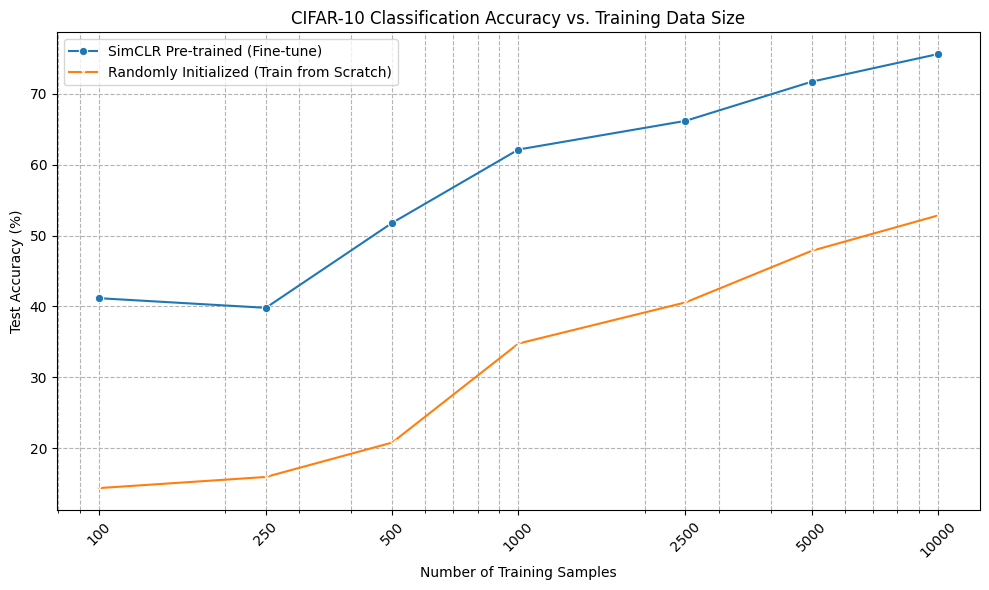

In [ ]:
# 3. Plotting the Results
plt.figure(figsize=(10, 6))
sns.lineplot(x=training_sizes, y=finetune_accuracies, marker='o', label='SimCLR Pre-trained (Fine-tune)')
sns.lineplot(x=training_sizes, y=scratch_accuracies, marker='x', label='Randomly Initialized (Train from Scratch)')

plt.title('CIFAR-10 Classification Accuracy vs. Training Data Size')
plt.xlabel('Number of Training Samples')
plt.ylabel('Test Accuracy (%)')
plt.xscale('log') # Use a log scale for better visualization of varying training sizes
plt.xticks(training_sizes, labels=[str(s) for s in training_sizes], rotation=45)
plt.grid(True, which="both", ls="--", c='0.7')
plt.legend()
plt.tight_layout()
plt.show()

### PCA Visualization of Embeddings

To further understand the quality of the learned representations, we will visualize the embeddings generated by our pre-trained SimCLR encoder using Principal Component Analysis (PCA). We will reduce the high-dimensional embeddings to 2 dimensions and plot them, coloring each point by its true CIFAR-10 class label. This will help us see if the model has learned to group similar classes together in the embedding space.

Extracting embeddings from the full training dataset...
Extracted 50000 embeddings.
PCA applied. Reduced embeddings to shape: (50000, 2)


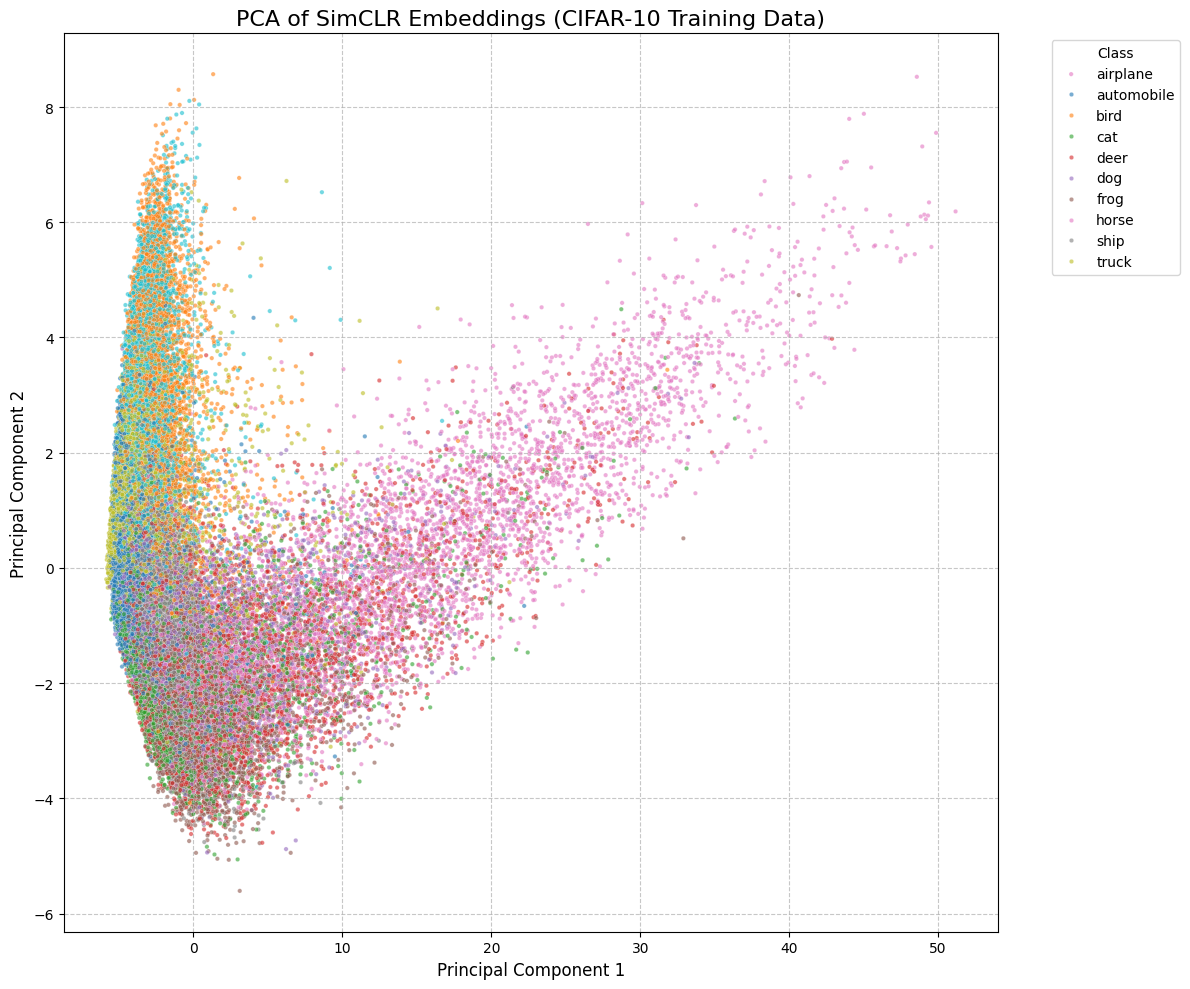

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

# 1. Prepare the full CIFAR-10 training dataset for embedding extraction
# Use the same eval_transform as for classification, no contrastive augs
train_cifar_full = torchvision.datasets.CIFAR10(root='./data', train=True, transform=eval_transform, download=True)
train_loader_full = DataLoader(train_cifar_full, batch_size=BATCH_SIZE, shuffle=False)

# 2. Extract Embeddings
model.eval() # Set model to evaluation mode
all_embeddings = []
all_labels = []

print("Extracting embeddings from the full training dataset...")
with torch.no_grad():
    for images, labels in train_loader_full:
        images = images.to(DEVICE)
        embeddings, _ = model(images)
        all_embeddings.append(embeddings.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_embeddings = np.concatenate(all_embeddings, axis=0)
all_labels = np.concatenate(all_labels, axis=0)
print(f"Extracted {len(all_embeddings)} embeddings.")

# 3. Apply PCA
pca = PCA(n_components=2)
pca_embeddings = pca.fit_transform(all_embeddings)
print(f"PCA applied. Reduced embeddings to shape: {pca_embeddings.shape}")

# Get CIFAR-10 class names for legend
class_names = train_cifar_full.classes

# 4. Plot Scatter Plot
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x=pca_embeddings[:, 0],
    y=pca_embeddings[:, 1],
    hue=all_labels,
    palette=sns.color_palette("tab10", n_colors=len(class_names)),
    legend="full",
    alpha=0.6,
    s=10 # point size
)

plt.title('PCA of SimCLR Embeddings (CIFAR-10 Training Data)', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Class', labels=class_names, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()